In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
#Load Processed data
df = pd.read_csv('../dataset/processed_data/processed_crime_data.csv')

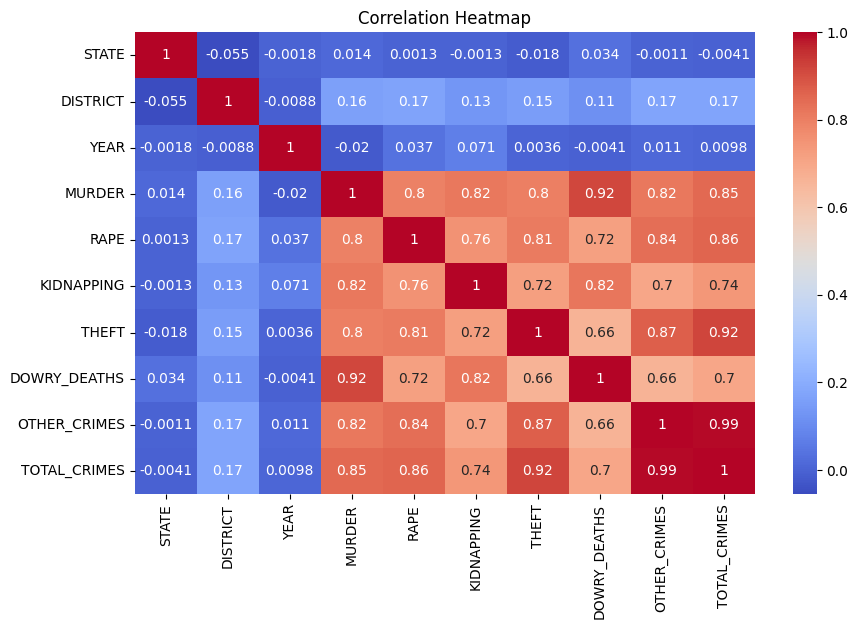

In [3]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig('../outputs/graphs/Correlation_Heatmap.png', bbox_inches='tight',dpi=100)
plt.show()

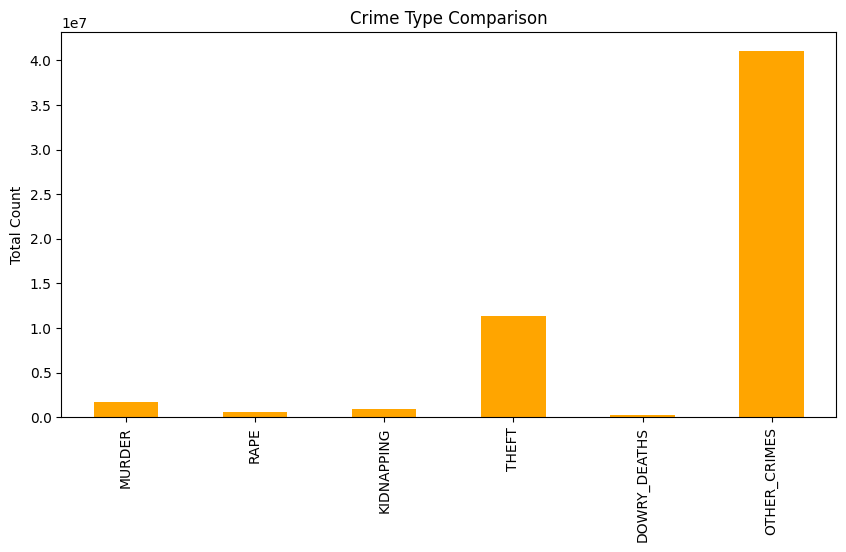

In [4]:
#Crime Type Comparison
crime_totals = df[['MURDER','RAPE','KIDNAPPING','THEFT','DOWRY_DEATHS','OTHER_CRIMES']].sum()

plt.figure(figsize=(10,5))
crime_totals.plot(kind='bar', color='orange')
plt.title("Crime Type Comparison")
plt.ylabel("Total Count")
plt.savefig('../outputs/graphs/Crime_Type_Comparison.png', bbox_inches='tight',dpi=100)
plt.show()

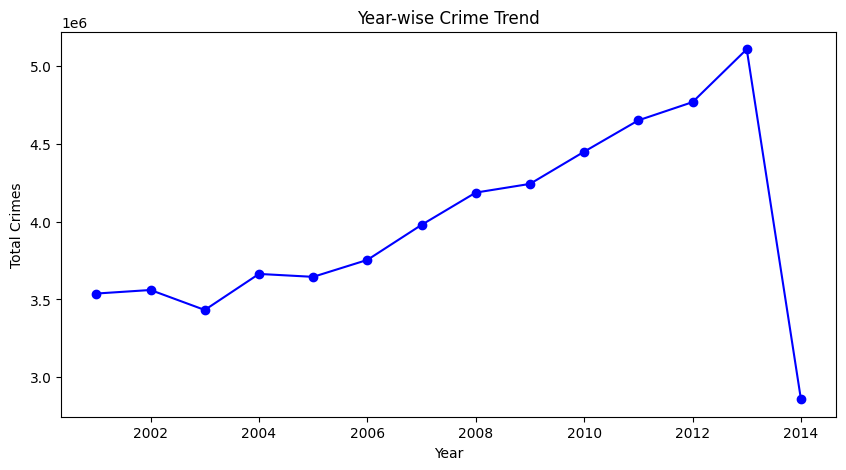

In [5]:
#Year vs Total Crimes
yearly = df.groupby('YEAR')['TOTAL_CRIMES'].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly, marker='o', linestyle='-', color='blue')
plt.title("Year-wise Crime Trend")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.savefig('../outputs/graphs/Crime_trend.png', bbox_inches='tight',dpi=100)
plt.show()

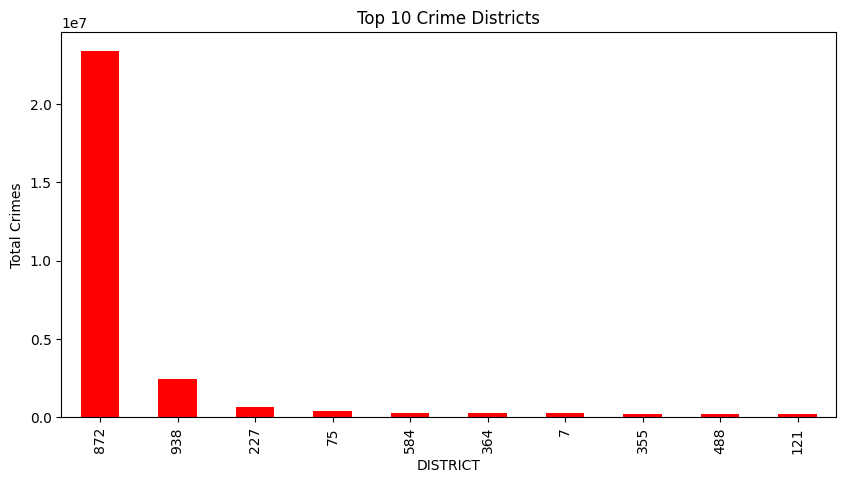

In [6]:
#Top Crime Districts
top_districts = df.groupby('DISTRICT')['TOTAL_CRIMES'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_districts.plot(kind='bar', color='red')
plt.title("Top 10 Crime Districts")
plt.ylabel("Total Crimes")
plt.savefig('../outputs/graphs/Top_districts.png', bbox_inches='tight',dpi=100)
plt.show()

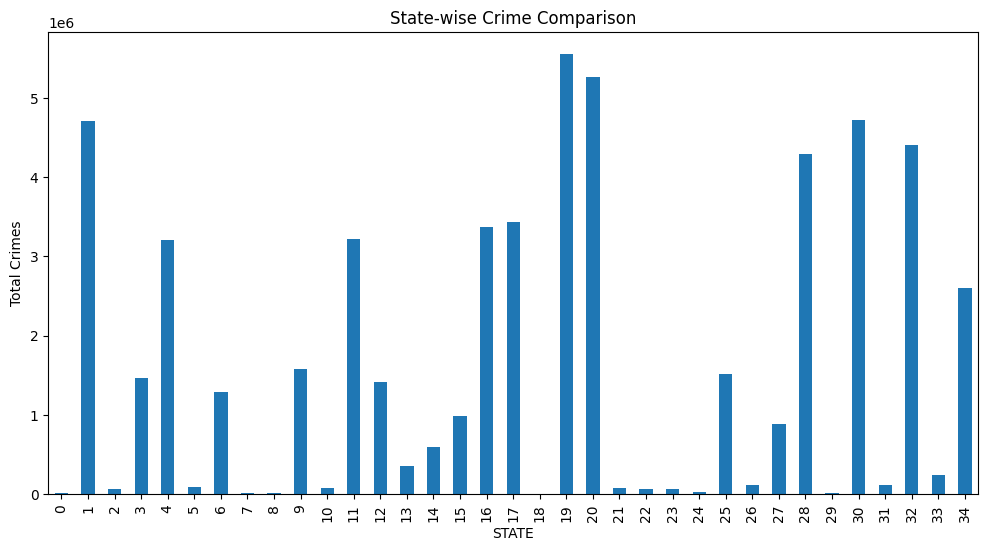

In [7]:
#State-wise Crime Comparison
state_crime = df.groupby('STATE')['TOTAL_CRIMES'].sum()

plt.figure(figsize=(12,6))
state_crime.plot(kind='bar')
plt.title("State-wise Crime Comparison")
plt.ylabel("Total Crimes")
plt.savefig('../outputs/graphs/Crime_comparison(state).png', bbox_inches='tight',dpi=100)
plt.show()

Cluster Means:
 cluster
0      3013.466731
2     76284.411215
1    171962.884211
Name: TOTAL_CRIMES, dtype: float64


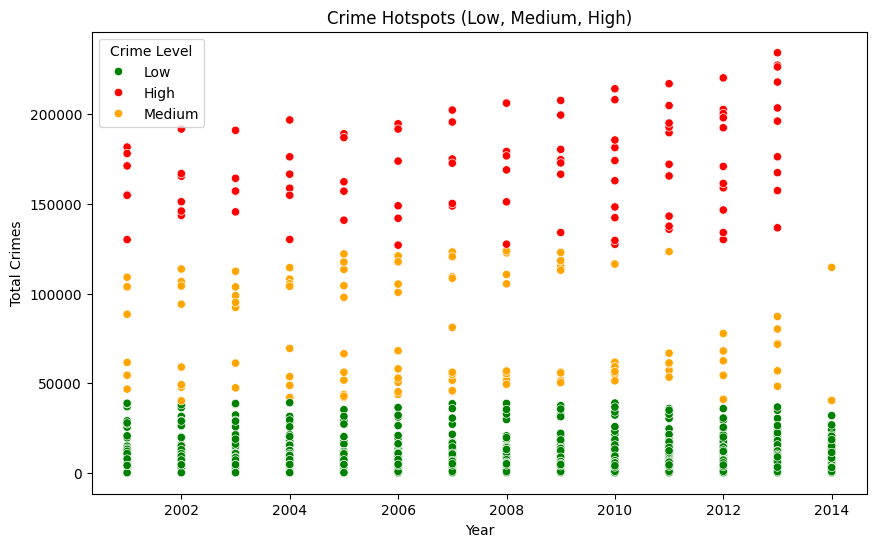

In [8]:
#KMeans Clustering (Hotspots)

# APPLY KMEANS
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['TOTAL_CRIMES']])

# CHECK CLUSTER MEAN VALUES
cluster_means = df.groupby('cluster')['TOTAL_CRIMES'].mean().sort_values()
print("Cluster Means:\n", cluster_means)

# MAP CLUSTERS TO LABELS
# Sort clusters based on crime values
cluster_mapping = {
    cluster_means.index[0]: 'Low',
    cluster_means.index[1]: 'Medium',
    cluster_means.index[2]: 'High'
}

df['crime_level'] = df['cluster'].map(cluster_mapping)

# COLOR MAPPING
color_map = {
    'Low': 'green',
    'Medium': 'orange',
    'High': 'red'
}

# PLOT GRAPH
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['YEAR'],
    y=df['TOTAL_CRIMES'],
    hue=df['crime_level'],
    palette=color_map
)

plt.title("Crime Hotspots (Low, Medium, High)")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.legend(title="Crime Level")
plt.savefig('../outputs/graphs/Crime_hotspots.png', bbox_inches='tight',dpi=100)
plt.show()

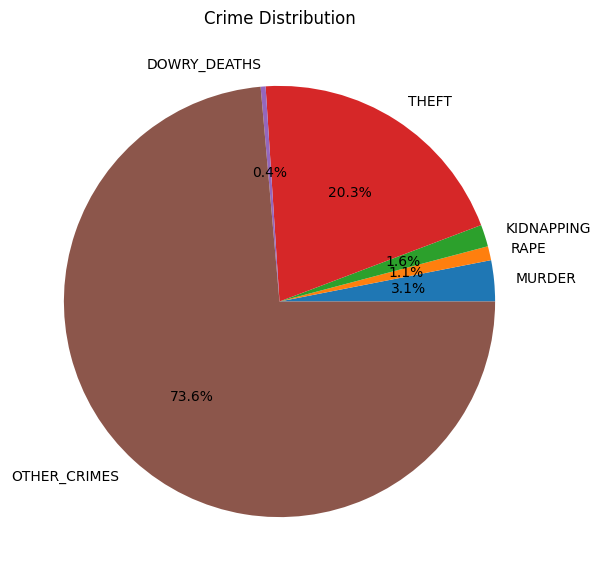

In [9]:
#Crime Distribution
crime_totals.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title("Crime Distribution")
plt.savefig('../outputs/graphs/Crime_distribution.png', bbox_inches='tight',dpi=100)
plt.show()